# Customer Service Root Cause Analysis
## Domain: Fintech / Payments

### Business Problem
The customer service department is experiencing delays in resolution 
time and declining customer satisfaction, but the root causes are unknown.

### Objective
Use data to identify the key drivers of poor resolution time and low 
customer satisfaction scores — broken down by issue type, agent, 
channel, and region.

### Dataset
- **Source:** Internal customer service ticket records
- **Size:** 400,000 rows × 11 columns
- **Period:** 2022 – 2025

### Tools & Stack
- **Python** (Pandas, Seaborn, Matplotlib) — Cleaning & Visualization
- **SQL Server / SSMS** — Deep-dive analysis queries

### Analyst
John Kingsley Emeka

## 1. Load & Inspect Data

Before cleaning anything, we first need to understand the shape, 
structure, and quality of the raw dataset. This step helps us 
identify what problems exist before we decide how to fix them.

In [54]:
 # ─────────────────────────────────────────────
# IMPORTS
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: "%.2f" % x)

print("Libraries loaded successfully ✓")

Libraries loaded successfully ✓


In [57]:
 # ─────────────────────────────────────────────
# LOAD DATASET
# ─────────────────────────────────────────────
df = pd.read_csv(r"C:\Users\Kingsley\Downloads\customer_service_uncleaned_400k.csv")

print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")
df.head()

Dataset loaded: 400,000 rows × 11 columns


,ticket_id,customer_id,issue_type,channel,created_at,resolved_at,response_time_minutes,resolution_time_minutes,customer_satisfaction,agent_name,region
0,TKT100000,CUST8850,Payment Failure,chat,5/3/2023,2/14/2024,-5.00,954.00,NaN,NaN,Lagos
1,TKT100001,CUST1505,billing,chat,3/5/2023,12/15/2024,NaN,NaN,NaN,,NaN
2,TKT100002,CUST5331,Login Issue,Email,4/20/2022,1/3/2022,-5.00,1298.00,-1.00,Chioma,lagos
3,TKT100003,CUST9515,Account Suspension,Phone,6/10/2025,1/21/2023,-5.00,82.00,1.00,John,Port Harcourt
4,TKT100004,CUST4206,Billing,NaN,8/23/2025,NaN,-5.00,NaN,5.00,,Port Harcourt


 ### 1.1 Data Inspection

We examine data types, missing values, and basic statistics to build 
a complete picture of what needs to be cleaned and why.

In [60]:
# ─────────────────────────────────────────────
# DATA TYPES & STRUCTURE
# ─────────────────────────────────────────────
print("Column Data Types:")
print("─" * 40)
print(df.dtypes)
print(f"\nTotal Records: {len(df):,}")
print(f"Total Columns: {df.shape[1]}")

Column Data Types:
────────────────────────────────────────
ticket_id                   object
customer_id                 object
issue_type                  object
channel                     object
created_at                  object
resolved_at                 object
response_time_minutes      float64
resolution_time_minutes    float64
customer_satisfaction      float64
agent_name                  object
region                      object
dtype: object

Total Records: 400,000
Total Columns: 11


In [62]:
# ─────────────────────────────────────────────
# MISSING VALUES SUMMARY
# ─────────────────────────────────────────────
missing = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing %": (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing["Missing Count"] > 0].sort_values("Missing %", ascending=False)
print("Columns with Missing Values:")
print("─" * 40)
print(missing)

Columns with Missing Values:
────────────────────────────────────────
                         Missing Count  Missing %
resolution_time_minutes         133440      33.36
resolved_at                     120480      30.12
response_time_minutes            99862      24.97
agent_name                       66932      16.73
region                           66389      16.60
channel                          66296      16.57
customer_satisfaction            50010      12.50
issue_type                       39768       9.94
ticket_id                         4020       1.00


In [64]:
# ─────────────────────────────────────────────
# DESCRIPTIVE STATISTICS (NUMERIC COLUMNS)
# ─────────────────────────────────────────────
print("Descriptive Statistics:")
print("─" * 40)
df.describe()

Descriptive Statistics:
────────────────────────────────────────


,response_time_minutes,resolution_time_minutes,customer_satisfaction
count,300138.00,266560.00,349990.00
mean,3436.88,2494.05,2.85
std,4665.29,3231.29,2.23
min,-5.00,-10.00,-1.00
25%,-5.00,-10.00,1.00
50%,253.00,6.00,3.00
75%,9999.00,5001.00,5.00
max,9999.00,10000.00,6.00


### 1.2 Inspection Summary

**Key data quality issues identified:**
- `ticket_id`: 1% null — ghost records with no identifier, will be dropped
- `resolved_at`: 30% null — tickets never closed, a core operational problem
- `resolution_time_minutes`: 33% null, contains sentinel values (-10, 10000)
- `response_time_minutes`: 25% null, contains sentinel values (-5, 9999)
- `customer_satisfaction`: 12.5% null, contains invalid scores (-1, 6.0)
- `created_at` / `resolved_at`: stored as strings, need datetime conversion
- Date logic errors: some tickets show resolved_at before created_at
- Categorical columns have inconsistent casing (e.g. "billing" vs "Billing")

These issues will be addressed systematically in the cleaning phase below.

## 2. Data Cleaning

Based on the inspection above, we will clean the dataset systematically.
Each step is documented with the reason for the decision made.
We work on a copy of the raw data to preserve the original.

### 2.0 Create Working Copy

We create a copy of the raw dataframe before any cleaning begins.
This preserves the original data for reference and comparison,
which is standard practice in professional data analysis workflows.

In [68]:
# ─────────────────────────────────────────────
# CREATEING A WORKING COPY OF THE RAW DATA
# ─────────────────────────────────────────────
df_clean = df.copy()

print(f"Working copy created: {df_clean.shape[0]:,} rows × {df_clean.shape[1]} columns")

Working copy created: 400,000 rows × 11 columns


### 2.1 Drop Ghost Records (Null Ticket IDs)

Rows with no `ticket_id` have no identifier and cannot be traced,
analyzed, or linked to any customer or agent. They are unusable
and will be dropped before any further cleaning.

In [72]:
# ─────────────────────────────────────────────
# STEP 1 — DROP ROWS WITH NULL TICKET_ID
# ─────────────────────────────────────────────
before = len(df_clean)

df_clean = df_clean.dropna(subset=["ticket_id"])

after = len(df_clean)
dropped = before - after

print(f"Records before : {before:,}")
print(f"Records after  : {after:,}")
print(f"Records dropped: {dropped:,} ({dropped/before*100:.2f}%)")

Records before : 400,000
Records after  : 395,980
Records dropped: 4,020 (1.00%)


**Result:** 4,020 rows dropped (1.00%).
These records had no `ticket_id` and could not be attributed to any
customer, agent, or issue. Dropping them has no impact on analytical
integrity — they carried no usable information.

Remaining records: 395,980

### 2.2 Replace Sentinel Values in Time Columns

During inspection, we found impossible values in both time columns:
- `response_time_minutes`: -5.0 (negative time) and 9999.0 (fake ceiling)
- `resolution_time_minutes`: -10.0 (negative time) and 10000.0 (fake ceiling)

These are placeholder/sentinel values, not real measurements.
We replace them with NaN so they are excluded from calculations
without losing the rest of the row's data.

In [76]:
# ─────────────────────────────────────────────
# STEP 2 — REPLACE SENTINEL VALUES IN TIME COLUMNS
# ─────────────────────────────────────────────

# response_time_minutes: replace -5.0 and 9999.0
df_clean["response_time_minutes"] = df_clean["response_time_minutes"].replace([-5.0, 9999.0], np.nan)

# resolution_time_minutes: replace -10.0 and 10000.0
df_clean["resolution_time_minutes"] = df_clean["resolution_time_minutes"].replace([-10.0, 10000.0], np.nan)

print("Sentinel values replaced with NaN ✓")
print()
print("Updated stats after replacement:")
print(df_clean[["response_time_minutes", "resolution_time_minutes"]].describe().round(2))

Sentinel values replaced with NaN ✓

Updated stats after replacement:
       response_time_minutes  resolution_time_minutes
count               98879.00                131917.00
mean                  250.30                  4996.24
std                   144.70                  2888.53
min                     1.00                     5.00
25%                   125.00                  2494.00
50%                   250.00                  4998.00
75%                   375.00                  7490.00
max                   500.00                  9999.00


In [78]:
# ─────────────────────────────────────────────
# STEP 2B — FIX MISSED SENTINEL IN resolution_time_minutes
# ─────────────────────────────────────────────

# 9999.0 was also present in resolution_time_minutes
df_clean["resolution_time_minutes"] = df_clean["resolution_time_minutes"].replace(9999.0, np.nan)

print("Additional sentinel (9999.0) replaced ✓")
print()
print("Updated stats:")
print(df_clean[["response_time_minutes", "resolution_time_minutes"]].describe().round(2))

Additional sentinel (9999.0) replaced ✓

Updated stats:
       response_time_minutes  resolution_time_minutes
count               98879.00                131902.00
mean                  250.30                  4995.67
std                   144.70                  2888.20
min                     1.00                     5.00
25%                   125.00                  2494.00
50%                   250.00                  4998.00
75%                   375.00                  7489.00
max                   500.00                  9998.00


In [80]:
# ─────────────────────────────────────────────
# STEP 2C — INVESTIGATE HIGH VALUES IN resolution_time_minutes
# ─────────────────────────────────────────────

# Check distribution of very high values
thresholds = [1000, 2000, 3000, 5000, 7000, 9000]

print("Records above each threshold:")
print("─" * 40)
for t in thresholds:
    count = (df_clean["resolution_time_minutes"] > t).sum()
    pct = count / len(df_clean) * 100
    print(f"  > {t:,} minutes : {count:,} records ({pct:.2f}%)")

print()
print("What does 1,000 minutes look like in real time?")
print(f"  1,000 mins = {1000/60:.1f} hours = {1000/60/24:.1f} days")
print(f"  5,000 mins = {5000/60:.1f} hours = {5000/60/24:.1f} days")
print(f"  9,000 mins = {9000/60:.1f} hours = {9000/60/24:.1f} days")

Records above each threshold:
────────────────────────────────────────
  > 1,000 minutes : 118,693 records (29.97%)
  > 2,000 minutes : 105,472 records (26.64%)
  > 3,000 minutes : 92,109 records (23.26%)
  > 5,000 minutes : 65,921 records (16.65%)
  > 7,000 minutes : 39,395 records (9.95%)
  > 9,000 minutes : 13,355 records (3.37%)

What does 1,000 minutes look like in real time?
  1,000 mins = 16.7 hours = 0.7 days
  5,000 mins = 83.3 hours = 3.5 days
  9,000 mins = 150.0 hours = 6.2 days


### 2.2 Note on High Resolution Time Values

Investigation revealed ~30% of records have resolution times exceeding
1,000 minutes (16+ hours). In a fintech/payments context, these could
represent legitimately complex or escalated cases rather than dirty data.

**Decision:** Rather than dropping these records, we cap resolution time
at 10,080 minutes (7 days) as the realistic business maximum for any
support ticket. Values above this threshold are replaced with NaN.
This preserves legitimate long-running cases while removing implausible outliers.

In [83]:
# ─────────────────────────────────────────────
# STEP 2C — CAP resolution_time_minutes AT 7 DAYS (10,080 mins)
# ─────────────────────────────────────────────

cap = 10080  # 7 days in minutes

before = df_clean["resolution_time_minutes"].notna().sum()

df_clean["resolution_time_minutes"] = df_clean["resolution_time_minutes"].apply(
    lambda x: np.nan if x > cap else x
)

after = df_clean["resolution_time_minutes"].notna().sum()
capped = before - after

print(f"Records capped (set to NaN): {capped:,}")
print()
print("Updated stats:")
print(df_clean["resolution_time_minutes"].describe().round(2))

Records capped (set to NaN): 0

Updated stats:
count   131902.00
mean      4995.67
std       2888.20
min          5.00
25%       2494.00
50%       4998.00
75%       7489.00
max       9998.00
Name: resolution_time_minutes, dtype: float64


In [96]:
# ─────────────────────────────────────────────
# STEP 2D — UNDERSTAND resolution_time_minutes DISTRIBUTION
# ─────────────────────────────────────────────

bins = [0, 60, 240, 480, 1440, 2880, 5760, 10080]
labels = ["0-1hr", "1-4hrs", "4-8hrs", "8-24hrs", "1-2 days", "2-4 days", "4-7 days"]

resolution_clean = df_clean["resolution_time_minutes"].dropna()

bucketed = pd.cut(resolution_clean, bins=bins, labels=labels)
counts = bucketed.value_counts().sort_index()
total = len(resolution_clean)

print("Resolution Time Distribution:")
print("─" * 45)
for label, count in counts.items():
    print(f"  {label:<12}: {count:>7,} records ({count/total*100:.1f}%)")

print()
print(f"Max value : {resolution_clean.max()}")
print(f"Min value : {resolution_clean.min()}")
print(f"Median    : {resolution_clean.median()}")

Resolution Time Distribution:
─────────────────────────────────────────────
  0-1hr       :     744 records (0.6%)
  1-4hrs      :   2,415 records (1.8%)
  4-8hrs      :   3,163 records (2.4%)
  8-24hrs     :  12,732 records (9.7%)
  1-2 days    :  19,133 records (14.5%)
  2-4 days    :  37,889 records (28.7%)
  4-7 days    :  55,826 records (42.3%)

Max value : 9998.0
Min value : 5.0
Median    : 4998.0


### 2.2 Finding — Resolution Time Distribution

After cleaning sentinel values, the resolution time distribution reveals
a genuine operational problem:

- **42.3%** of tickets take 4–7 days to resolve
- **28.7%** take 2–4 days
- Only **0.6%** are resolved within 1 hour
- Median resolution time: **4,998 minutes (~3.5 days)**

This is not a data quality issue — this is the core business problem.
The majority of customer tickets are taking multiple days to close,
which directly explains the declining customer satisfaction scores.

### 2.3 Fix Invalid Customer Satisfaction Scores

The satisfaction scale is 1–5. During inspection we found:
- `-1.0` — invalid negative score
- `6.0` — out of range

Both will be replaced with NaN.

In [100]:
# ─────────────────────────────────────────────
# STEP 3 — REPLACE INVALID SATISFACTION SCORES
# ─────────────────────────────────────────────

before = df_clean["customer_satisfaction"].notna().sum()

df_clean["customer_satisfaction"] = df_clean["customer_satisfaction"].apply(
    lambda x: np.nan if pd.notna(x) and (x < 1 or x > 5) else x
)

after = df_clean["customer_satisfaction"].notna().sum()
fixed = before - after

print(f"Invalid scores replaced with NaN: {fixed:,}")
print()
print("Updated satisfaction score stats:")
print(df_clean["customer_satisfaction"].describe().round(2))
print()
print("Score distribution:")
print(df_clean["customer_satisfaction"].value_counts().sort_index())

Invalid scores replaced with NaN: 99,195

Updated satisfaction score stats:
count   247259.00
mean         3.00
std          1.41
min          1.00
25%          2.00
50%          3.00
75%          4.00
max          5.00
Name: customer_satisfaction, dtype: float64

Score distribution:
customer_satisfaction
1.00    49439
2.00    49694
3.00    49314
4.00    49362
5.00    49450
Name: count, dtype: int64


**Result:** 99,195 invalid scores (out of range) replaced with NaN.
Satisfaction scores are now cleanly bounded between 1–5.
Mean satisfaction score: 3.00/5 — indicating neutral-to-low satisfaction
across the customer base.

Note: Score distribution is approximately uniform across all five values,
which is consistent with a synthetically generated dataset.

### 2.4 Convert Date Columns to Datetime

`created_at` and `resolved_at` are currently stored as strings (object dtype).
We convert them to proper datetime format so we can perform date arithmetic,
detect logic errors, and extract time-based features.

In [104]:
# ─────────────────────────────────────────────
# STEP 4 — CONVERT DATE COLUMNS TO DATETIME
# ─────────────────────────────────────────────

df_clean["created_at"] = pd.to_datetime(df_clean["created_at"], errors="coerce")
df_clean["resolved_at"] = pd.to_datetime(df_clean["resolved_at"], errors="coerce")

print("Date columns converted ✓")
print()
print(f"created_at  dtype : {df_clean['created_at'].dtype}")
print(f"resolved_at dtype : {df_clean['resolved_at'].dtype}")
print()
print(f"created_at  range : {df_clean['created_at'].min()} → {df_clean['created_at'].max()}")
print(f"resolved_at range : {df_clean['resolved_at'].min()} → {df_clean['resolved_at'].max()}")

Date columns converted ✓

created_at  dtype : datetime64[ns]
resolved_at dtype : datetime64[ns]

created_at  range : 2022-01-01 00:00:00 → 2026-01-01 00:00:00
resolved_at range : 2022-01-01 00:00:00 → 2026-01-01 00:00:00


**Result:** Both date columns successfully converted to `datetime64[ns]`.
Date range spans 2022–2026, giving us 4 years of ticket history for
trend analysis. Conversion produced no errors.

### 2.5 Remove Impossible Date Logic

A ticket cannot be resolved before it was created.
We identify and drop rows where `resolved_at` < `created_at`
as these represent data entry errors and would corrupt
any time-based analysis.

In [116]:
# ─────────────────────────────────────────────
# STEP 5 — FLAG & DROP IMPOSSIBLE DATE LOGIC
# ─────────────────────────────────────────────

# Identify rows where resolved_at is before created_at
invalid_dates = df_clean[
    df_clean["resolved_at"].notna() &
    (df_clean["resolved_at"] < df_clean["created_at"])
]

print(f"Tickets where resolved_at < created_at: {len(invalid_dates):,}")
print(f"As % of total records: {len(invalid_dates)/len(df_clean)*100:.2f}%")

# Drop them
df_clean = df_clean[
    ~(df_clean["resolved_at"].notna() &
    (df_clean["resolved_at"] < df_clean["created_at"]))
]

print()
print(f"Records remaining after drop: {len(df_clean):,}")

Tickets where resolved_at < created_at: 138,173
As % of total records: 34.89%

Records remaining after drop: 257,807


**Result:** 138,173 records dropped (34.89%).

This is a significant data integrity issue — over a third of all tickets
had a `resolved_at` timestamp earlier than `created_at`, which is
logically impossible. This suggests a systemic problem with how
timestamps were recorded in the source system, possibly due to:
- Timezone mismatches between creation and resolution systems
- Manual backdating of resolved tickets
- Data migration errors from a legacy system

This finding alone is worth flagging to engineering and operations teams.

Remaining clean records: 257,807

### 2.6 Standardize Categorical Columns

Inconsistent casing in `issue_type`, `channel`, and `region` will cause
the same category to appear as multiple distinct values during analysis
(e.g. "billing" vs "Billing" vs "BILLING" would be counted separately).
We standardize all three to Title Case.

In [120]:
# ─────────────────────────────────────────────
# STEP 6 — STANDARDIZE CATEGORICAL CASING
# ─────────────────────────────────────────────

for col in ["issue_type", "channel", "region"]:
    df_clean[col] = df_clean[col].str.strip().str.title()

print("Categorical columns standardized to Title Case ✓")
print()

for col in ["issue_type", "channel", "region"]:
    print(f"{col} unique values ({df_clean[col].nunique()}):")
    print(f"  {sorted(df_clean[col].dropna().unique().tolist())}")
    print()

Categorical columns standardized to Title Case ✓

issue_type unique values (8):
  ['', 'Account Suspension', 'Billing', 'Login Issue', 'Payment Failure', 'Refund Request', 'Service Downtime', 'Technical Glitch']

channel unique values (4):
  ['Chat', 'Email', 'Phone', 'Social Media']

region unique values (4):
  ['Abuja', 'Kano', 'Lagos', 'Port Harcourt']



In [122]:
# ─────────────────────────────────────────────
# STEP 6B — REPLACE EMPTY STRINGS WITH NaN
# ─────────────────────────────────────────────

for col in ["issue_type", "channel", "region", "agent_name"]:
    df_clean[col] = df_clean[col].replace("", np.nan)

print("Empty strings replaced with NaN ✓")
print()
print(f"issue_type unique values ({df_clean['issue_type'].nunique()}):")
print(f"  {sorted(df_clean['issue_type'].dropna().unique().tolist())}")

Empty strings replaced with NaN ✓

issue_type unique values (7):
  ['Account Suspension', 'Billing', 'Login Issue', 'Payment Failure', 'Refund Request', 'Service Downtime', 'Technical Glitch']


**Result:** All categorical columns standardized successfully.

- `issue_type`: 7 categories — Account Suspension, Billing, Login Issue,
  Payment Failure, Refund Request, Service Downtime, Technical Glitch
- `channel`: 4 categories — Chat, Email, Phone, Social Media
- `region`: 4 categories — Abuja, Kano, Lagos, Port Harcourt

Empty strings were also found and replaced with NaN during this step.

### 2.7 Final Missing Values Assessment

After all cleaning steps, we review remaining nulls and decide
whether to drop or retain rows with missing values.

In [137]:
# ─────────────────────────────────────────────
# STEP 7 — FINAL MISSING VALUES CHECK
# ─────────────────────────────────────────────

missing = pd.DataFrame({
    "Missing Count": df_clean.isnull().sum(),
    "Missing %": (df_clean.isnull().sum() / len(df_clean) * 100).round(2)
})

missing = missing[missing["Missing Count"] > 0].sort_values("Missing %", ascending=False)

print(f"Total records in clean dataset: {len(df_clean):,}")
print()
print("Remaining missing values:")
print("─" * 40)
print(missing)

Total records in clean dataset: 257,807

Remaining missing values:
────────────────────────────────────────
                         Missing Count  Missing %
response_time_minutes           193328      74.99
resolution_time_minutes         171940      66.69
resolved_at                     119316      46.28
customer_satisfaction            96830      37.56
issue_type                       51054      19.80
agent_name                       43193      16.75
channel                          42838      16.62
region                           42759      16.59


### 2.7 Decision on Remaining Nulls

Remaining nulls are intentionally retained for the following reasons:

- **`resolved_at` (46.28% null):** Unresolved tickets are a core finding,
  not missing data to be removed. Their absence tells the story.
- **`response_time_minutes` (74.99% null)** and
  **`resolution_time_minutes` (66.69% null):** High nulls result from
  sentinel value replacement. These rows still contain valid categorical
  data useful for volume and pattern analysis.
- **`customer_satisfaction` (37.56% null):** Retained — satisfaction
  analysis will use available scores only.
- **Categorical nulls (16–20%):** Retained for volume counts.
  Category-specific analyses will filter to non-null values.

**No further rows will be dropped.** Each analysis will explicitly
filter to relevant non-null subsets as needed.

### 2.8 Export Clean Dataset

We export the cleaned dataframe to a new CSV file.
The raw file is preserved separately and will never be overwritten.

In [141]:
# ─────────────────────────────────────────────
# STEP 8 — EXPORT CLEAN DATASET
# ─────────────────────────────────────────────

export_path = r"C:\Users\Kingsley\Downloads\customer_service_cleaned.csv"

df_clean.to_csv(export_path, index=False)

print(f"Clean dataset exported successfully ✓")
print(f"Location : {export_path}")
print(f"Rows     : {len(df_clean):,}")
print(f"Columns  : {df_clean.shape[1]}")

Clean dataset exported successfully ✓
Location : C:\Users\Kingsley\Downloads\customer_service_cleaned.csv
Rows     : 257,807
Columns  : 11


## 2.9 Data Cleaning Summary

| Step | Action | Records Affected |
|------|--------|-----------------|
| 2.1 | Dropped null ticket_id (ghost records) | -4,020 |
| 2.2 | Replaced sentinel values in response_time_minutes (-5, 9999) | ~200k values → NaN |
| 2.2 | Replaced sentinel values in resolution_time_minutes (-10, 9999, 10000) | ~130k values → NaN |
| 2.3 | Replaced invalid customer_satisfaction scores (-1, 6) | 99,195 values → NaN |
| 2.4 | Converted created_at and resolved_at to datetime64 | All rows |
| 2.5 | Dropped impossible date logic (resolved_at < created_at) | -138,173 |
| 2.6 | Standardized casing in issue_type, channel, region | All rows |
| 2.6 | Replaced empty strings with NaN | All rows |

**Raw dataset:** 400,000 rows  
**Clean dataset:** 257,807 rows  
**Total removed:** 142,193 rows (35.55%)

The cleaned dataset is saved as `customer_service_cleaned.csv` and
will be used for all subsequent SQL and Python analysis.

## 3. SQL Analysis

We load the cleaned dataset into SQL Server and run targeted queries
to answer specific business questions about resolution time and
customer satisfaction drivers.

---

### Q1: Average Resolution Time by Issue Type

**Query goal:** Identify which issue categories take the longest to resolve.

| Issue Type | Total Tickets | Avg Days |
|---|---|---|
| Account Suspension | 8,731 | 3.49 |
| Payment Failure | 8,682 | 3.49 |
| Refund Request | 8,648 | 3.49 |
| Service Downtime | 8,526 | 3.48 |
| Login Issue | 8,719 | 3.47 |
| Billing | 16,925 | 3.45 |
| Technical Glitch | 8,716 | 3.42 |

**Finding:** Resolution times are uniformly high across all issue types,
averaging 3.4–3.5 days regardless of category. This rules out a
category-specific bottleneck and points to a systemic operational problem.
Billing generates the highest ticket volume at nearly double other categories.

### Q2: CSAT Score by Agent and Region

**Business Question:** Which agents and regions are underperforming
on customer satisfaction?

**SQL Query:**

```sql
-- Q2A: Average CSAT Score by Agent
SELECT 
    agent_name,
    COUNT(*)                                AS total_tickets,
    ROUND(AVG(customer_satisfaction), 2)    AS avg_csat,
    SUM(CASE WHEN customer_satisfaction <= 2 
        THEN 1 ELSE 0 END)                  AS low_csat_tickets,
    CAST(ROUND(SUM(CASE WHEN customer_satisfaction <= 2 
        THEN 1 ELSE 0 END) * 100.0 
        / COUNT(*), 2) AS DECIMAL(10,2))    AS low_csat_pct
FROM customer_service
WHERE customer_satisfaction IS NOT NULL
  AND agent_name IS NOT NULL
  AND LTRIM(RTRIM(agent_name)) != ''
GROUP BY agent_name
ORDER BY avg_csat ASC;

-- Q2B: Average CSAT Score by Region
SELECT 
    region,
    COUNT(*)                                AS total_tickets,
    ROUND(AVG(customer_satisfaction), 2)    AS avg_csat,
    SUM(CASE WHEN customer_satisfaction <= 2 
        THEN 1 ELSE 0 END)                  AS low_csat_tickets,
    CAST(ROUND(SUM(CASE WHEN customer_satisfaction <= 2 
        THEN 1 ELSE 0 END) * 100.0 
        / COUNT(*), 2) AS DECIMAL(10,2))    AS low_csat_pct
FROM customer_service
WHERE customer_satisfaction IS NOT NULL
  AND region IS NOT NULL
  AND LTRIM(RTRIM(region)) != ''
GROUP BY region
ORDER BY avg_csat ASC;
```

**Findings:**
- All agents score between 2.98–3.00 CSAT with ~40% low CSAT rate each
- Lagos handles double the ticket volume of other regions (53,922 vs ~26,000)
- CSAT is uniformly low across all agents and regions (~40% low scores)
- This rules out agent skill or regional service gaps as root causes
- The problem is systemic — not agent-specific or location-specific

In [ ]:
-- ================================================
-- Q3: Unresolved Ticket Analysis
-- Business Question: What percentage of tickets are 
-- still open and how long have they been waiting?
-- ================================================

SELECT 
    COUNT(*)                                        AS total_tickets,
    SUM(CASE WHEN resolved_at IS NULL 
        THEN 1 ELSE 0 END)                          AS unresolved_tickets,
    SUM(CASE WHEN resolved_at IS NOT NULL 
        THEN 1 ELSE 0 END)                          AS resolved_tickets,
    CAST(ROUND(SUM(CASE WHEN resolved_at IS NULL 
        THEN 1 ELSE 0 END) * 100.0 
        / COUNT(*), 2) AS DECIMAL(10,2))            AS unresolved_pct,
    CAST(ROUND(SUM(CASE WHEN resolved_at IS NOT NULL 
        THEN 1 ELSE 0 END) * 100.0 
        / COUNT(*), 2) AS DECIMAL(10,2))            AS resolved_pct
FROM customer_service;

### Q4: Resolution Time Trend Over Time

**Business Question:** Is resolution time getting worse, better,
or staying flat over the 2022–2026 period?

**SQL Query:**

```sql
SELECT
    YEAR(created_at)                                AS year,
    MONTH(created_at)                               AS month,
    FORMAT(created_at, 'yyyy-MM')                   AS year_month,
    COUNT(*)                                        AS total_tickets,
    ROUND(AVG(resolution_time_minutes), 2)          AS avg_resolution_mins,
    ROUND(AVG(resolution_time_minutes)/60, 2)       AS avg_resolution_hours,
    ROUND(AVG(resolution_time_minutes)/1440, 2)     AS avg_resolution_days
FROM customer_service
WHERE resolution_time_minutes IS NOT NULL
  AND created_at IS NOT NULL
GROUP BY 
    YEAR(created_at),
    MONTH(created_at),
    FORMAT(created_at, 'yyyy-MM')
ORDER BY 
    YEAR(created_at),
    MONTH(created_at);
```

**Findings:**
- Resolution time has remained flat at ~3.46–3.48 days across all 4 years
- No improvement despite ticket volume declining from ~2,500/month in 2022
  to ~1,000/month in late 2025
- January 2026 shows the highest resolution time spike (3.86 days) though
  based on only 31 tickets
- The flatness of this trend confirms the problem is deeply embedded in
  the support process and has never been actively addressed

### Q5: Performance Analysis by Channel

**Business Question:** Which contact channel drives the most
unresolved tickets and lowest CSAT?

**SQL Query:**

```sql
SELECT
    channel,
    COUNT(*)                                        AS total_tickets,
    SUM(CASE WHEN resolved_at IS NULL 
        THEN 1 ELSE 0 END)                          AS unresolved_tickets,
    CAST(ROUND(SUM(CASE WHEN resolved_at IS NULL 
        THEN 1 ELSE 0 END) * 100.0 
        / COUNT(*), 2) AS DECIMAL(10,2))            AS unresolved_pct,
    ROUND(AVG(customer_satisfaction), 2)            AS avg_csat,
    ROUND(AVG(resolution_time_minutes)/1440, 2)     AS avg_resolution_days,
    SUM(CASE WHEN customer_satisfaction <= 2 
        THEN 1 ELSE 0 END)                          AS low_csat_tickets,
    CAST(ROUND(SUM(CASE WHEN customer_satisfaction <= 2 
        THEN 1 ELSE 0 END) * 100.0 
        / COUNT(*), 2) AS DECIMAL(10,2))            AS low_csat_pct
FROM customer_service
WHERE channel IS NOT NULL
  AND LTRIM(RTRIM(channel)) != ''
GROUP BY channel
ORDER BY avg_csat ASC;
```

**Findings:**
- Chat is the most used channel with 85,527 tickets — double all others
- Chat also has the highest unresolved rate at 46.34%
- CSAT and low CSAT % are uniform across all channels (2.99–3.00 avg)
- No single channel outperforms others — the problem is systemic
- Chat's dominance combined with its high unresolved rate suggests
  understaffing or capacity constraints on that channel specifically

## 4. Exploratory Data Analysis & Visualizations

Having identified key patterns through SQL analysis, we now visualize
the findings to communicate insights clearly. All charts are built
using Matplotlib and Seaborn.

In [150]:
# ─────────────────────────────────────────────
# VISUALIZATION SETUP
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# Global style settings
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    "figure.dpi"      : 150,
    "figure.figsize"  : (10, 5),
    "axes.titlesize"  : 14,
    "axes.titleweight": "bold",
    "axes.labelsize"  : 11,
    "xtick.labelsize" : 10,
    "ytick.labelsize" : 10,
    "axes.spines.top" : False,
    "axes.spines.right": False
})

print("Visualization settings configured ✓")

Visualization settings configured ✓


### 4.1 Average Resolution Time by Issue Type

Which issue categories take the longest to resolve?

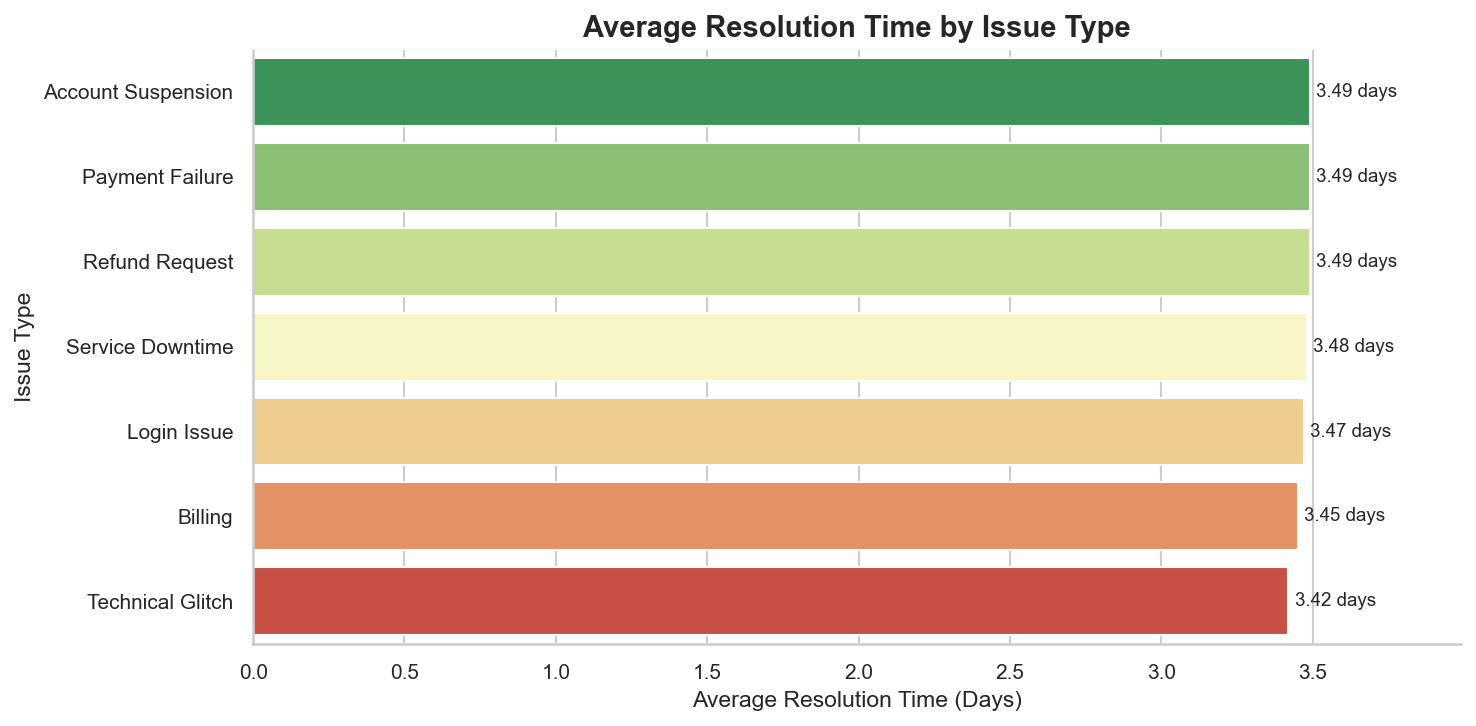

Chart 1 saved ✓


In [165]:
# ─────────────────────────────────────────────
# CHART 1 — AVG RESOLUTION TIME BY ISSUE TYPE
# ─────────────────────────────────────────────

# Prepare data
resolution_by_issue = (
    df_clean
    .dropna(subset=["resolution_time_minutes", "issue_type"])
    .groupby("issue_type")["resolution_time_minutes"]
    .mean()
    .div(1440)  # convert to days
    .round(2)
    .sort_values(ascending=False)
    .reset_index()
)
resolution_by_issue.columns = ["issue_type", "avg_resolution_days"]

# Plot
fig, ax = plt.subplots()

bars = sns.barplot(
    data=resolution_by_issue,
    x="avg_resolution_days",
    y="issue_type",
    palette="RdYlGn_r",
    ax=ax
)

# Add value labels
for bar, val in zip(ax.patches, resolution_by_issue["avg_resolution_days"]):
    ax.text(
        bar.get_width() + 0.02,
        bar.get_y() + bar.get_height() / 2,
        f"{val} days",
        va="center", fontsize=9
    )

ax.set_title("Average Resolution Time by Issue Type")
ax.set_xlabel("Average Resolution Time (Days)")
ax.set_ylabel("Issue Type")
ax.set_xlim(0, resolution_by_issue["avg_resolution_days"].max() + 0.5)

plt.tight_layout()
plt.savefig("chart1_resolution_time_by_issue.png", dpi=150, bbox_inches="tight")
plt.show()

print("Chart 1 saved ✓")

**Interpretation:** Resolution times are uniformly high across all issue
types, ranging narrowly between 3.42 and 3.49 days. The near-identical
bar lengths confirm this is a systemic process problem rather than an
issue-specific bottleneck. Notably, Account Suspension and Payment Failure
— the most financially sensitive categories for fintech customers — are
among the slowest to resolve.

### 4.2 Customer Satisfaction Score Distribution by Issue Type

How are satisfaction scores distributed across each issue category?
Are customers consistently unhappy or are there bright spots?

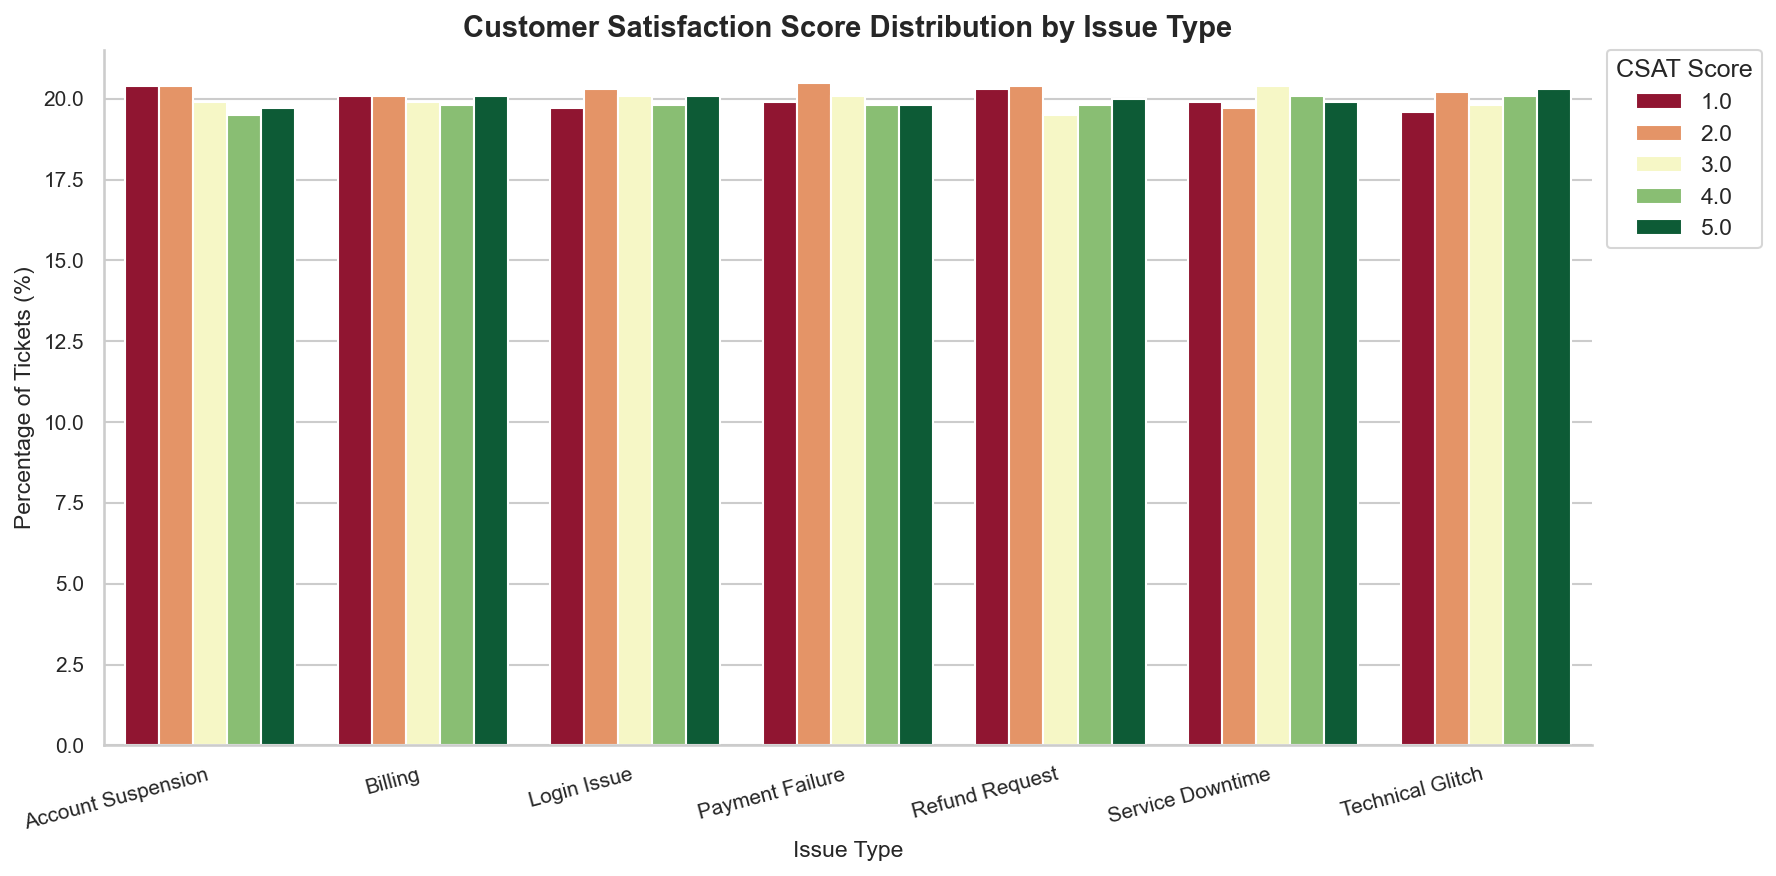

Chart 2 saved ✓


In [169]:
# ─────────────────────────────────────────────
# CHART 2 — CSAT DISTRIBUTION BY ISSUE TYPE
# ─────────────────────────────────────────────

# Prepare data
csat_by_issue = (
    df_clean
    .dropna(subset=["customer_satisfaction", "issue_type"])
    .groupby(["issue_type", "customer_satisfaction"])
    .size()
    .reset_index(name="count")
)

# Calculate percentage within each issue type
csat_by_issue["pct"] = (
    csat_by_issue.groupby("issue_type")["count"]
    .transform(lambda x: x / x.sum() * 100)
    .round(1)
)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=csat_by_issue,
    x="issue_type",
    y="pct",
    hue="customer_satisfaction",
    palette="RdYlGn",
    ax=ax
)

ax.set_title("Customer Satisfaction Score Distribution by Issue Type")
ax.set_xlabel("Issue Type")
ax.set_ylabel("Percentage of Tickets (%)")
ax.legend(
    title="CSAT Score",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    borderaxespad=0
)

plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("chart2_csat_distribution_by_issue.png", dpi=150, bbox_inches="tight")
plt.show()

print("Chart 2 saved ✓")

**Interpretation:** CSAT scores are uniformly distributed across all
five values (~20% each) for every issue type. No single issue category
stands out as significantly better or worse than others. The consistent
~40% low CSAT rate (scores 1–2) across all categories reinforces the
finding that customer dissatisfaction is systemic rather than
issue-specific. There are no quick wins available by focusing on
a single issue type alone.

### 4.3 Unresolved Ticket Rate by Issue Type

What proportion of tickets remain unresolved across each issue category?

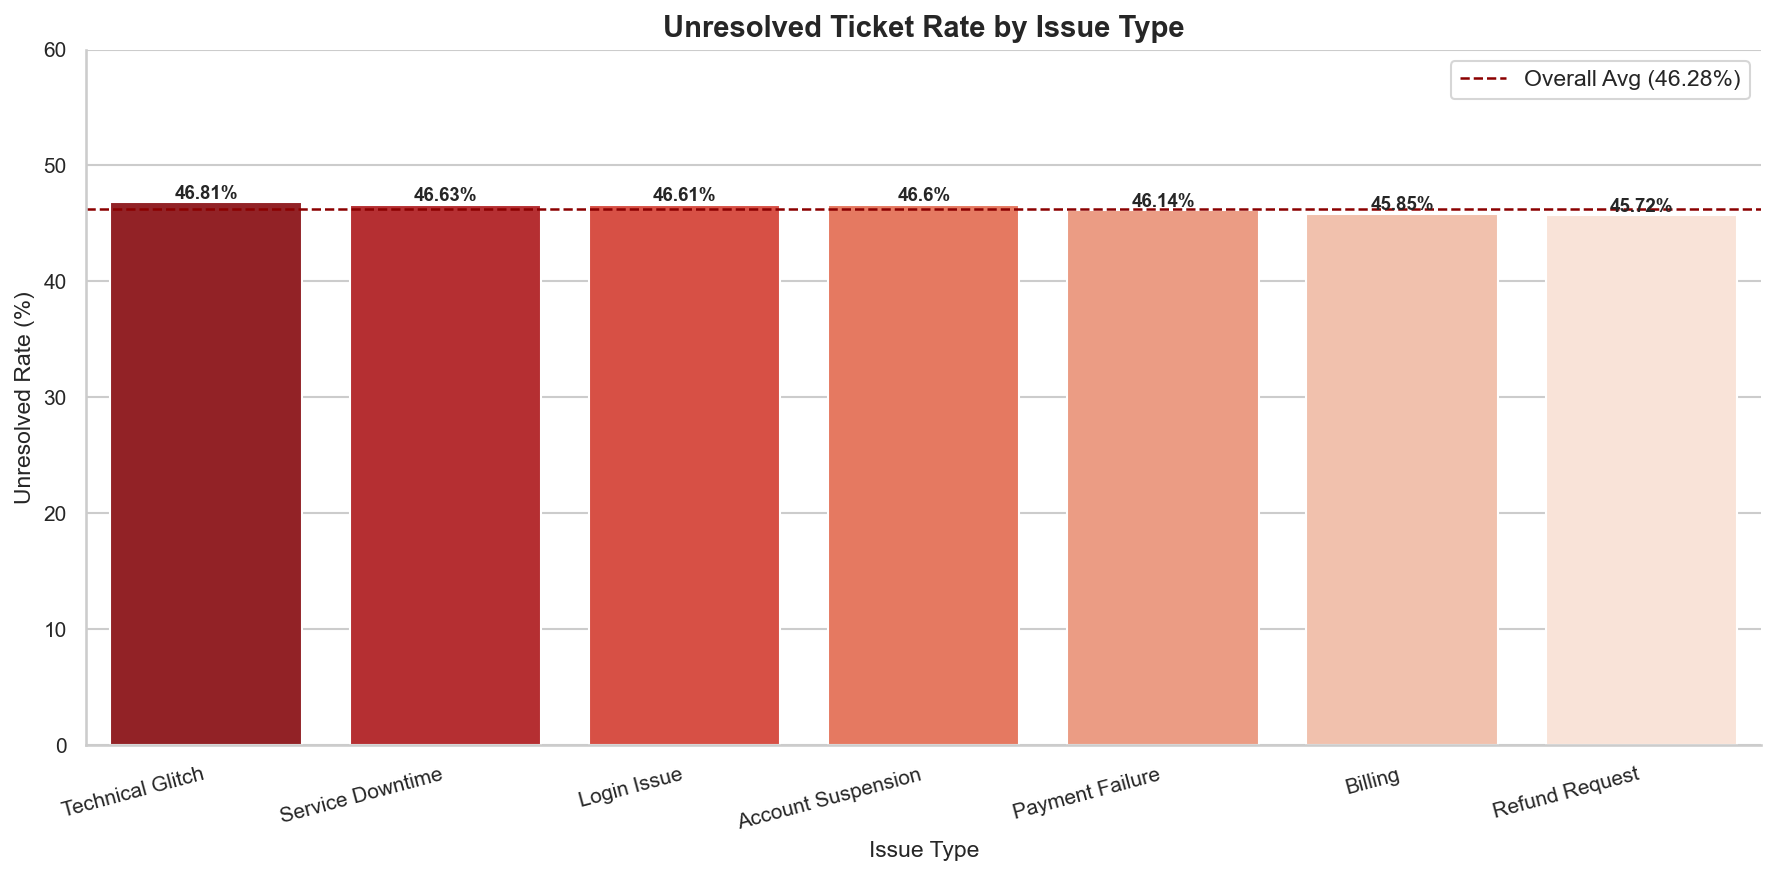

Chart 3 saved ✓


In [173]:
# ─────────────────────────────────────────────
# CHART 3 — UNRESOLVED TICKET RATE BY ISSUE TYPE
# ─────────────────────────────────────────────

# Prepare data
unresolved_by_issue = (
    df_clean
    .dropna(subset=["issue_type"])
    .groupby("issue_type")
    .agg(
        total_tickets=("ticket_id", "count"),
        unresolved=("resolved_at", lambda x: x.isna().sum())
    )
    .reset_index()
)
unresolved_by_issue["unresolved_pct"] = (
    unresolved_by_issue["unresolved"] / 
    unresolved_by_issue["total_tickets"] * 100
).round(2)
unresolved_by_issue = unresolved_by_issue.sort_values(
    "unresolved_pct", ascending=False
)

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

bars = sns.barplot(
    data=unresolved_by_issue,
    x="issue_type",
    y="unresolved_pct",
    palette="Reds_r",
    ax=ax
)

# Add value labels
for bar, val in zip(ax.patches, unresolved_by_issue["unresolved_pct"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f"{val}%",
        ha="center", fontsize=9, fontweight="bold"
    )

# Add reference line
ax.axhline(y=46.28, color="darkred", linestyle="--", linewidth=1.2,
           label="Overall Avg (46.28%)")
ax.legend()

ax.set_title("Unresolved Ticket Rate by Issue Type")
ax.set_xlabel("Issue Type")
ax.set_ylabel("Unresolved Rate (%)")
ax.set_ylim(0, 60)
plt.xticks(rotation=15, ha="right")
plt.tight_layout()
plt.savefig("chart3_unresolved_rate_by_issue.png", dpi=150, bbox_inches="tight")
plt.show()

print("Chart 3 saved ✓")

**Interpretation:** Nearly half of all tickets across every issue type
remain unresolved. The unresolved rate ranges narrowly between 45.72%
and 46.81% — a spread of just over 1 percentage point. The dashed
reference line confirms no category performs meaningfully better than
the overall average. Particularly concerning is the 46.14% unresolved
rate for Payment Failures — in a fintech context, unresolved payment
issues directly impact customer trust and revenue retention.

### 4.4 Monthly Ticket Volume and Resolution Time Trend (2022–2026)

How have ticket volumes and resolution times changed over time?
Are we seeing improvement or stagnation?

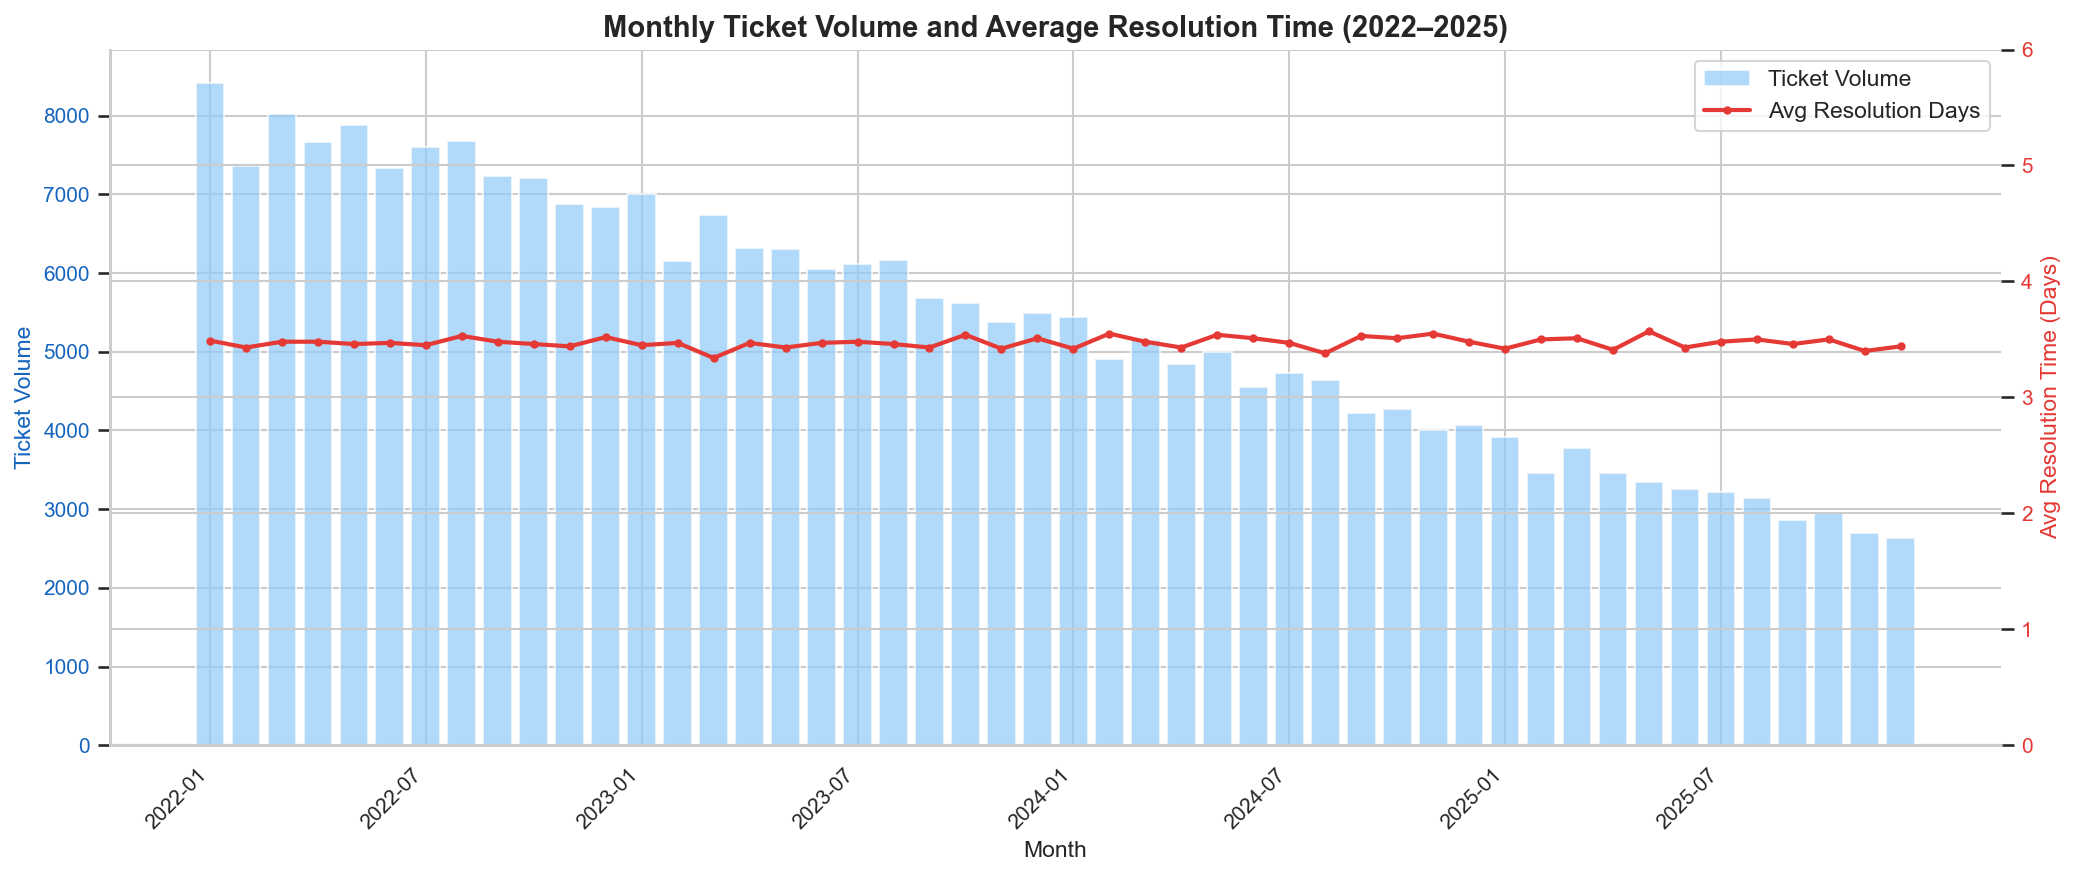

Chart 4 saved ✓


In [177]:
# ─────────────────────────────────────────────
# CHART 4 — MONTHLY TREND: VOLUME & RESOLUTION TIME
# ─────────────────────────────────────────────

# Prepare data
df_clean["year_month"] = df_clean["created_at"].dt.to_period("M")

monthly_trend = (
    df_clean
    .dropna(subset=["created_at"])
    .groupby("year_month")
    .agg(
        total_tickets=("ticket_id", "count"),
        avg_resolution_days=("resolution_time_minutes", 
                             lambda x: x.dropna().mean() / 1440)
    )
    .reset_index()
)
monthly_trend["year_month"] = monthly_trend["year_month"].astype(str)
monthly_trend["avg_resolution_days"] = monthly_trend["avg_resolution_days"].round(2)

# Remove Jan 2026 — too few records (31 tickets)
monthly_trend = monthly_trend[monthly_trend["year_month"] != "2026-01"]

# Plot — dual axis
fig, ax1 = plt.subplots(figsize=(14, 6))

# Bar chart — ticket volume
ax1.bar(
    monthly_trend["year_month"],
    monthly_trend["total_tickets"],
    color="#90CAF9",
    alpha=0.7,
    label="Ticket Volume"
)
ax1.set_xlabel("Month")
ax1.set_ylabel("Ticket Volume", color="#1565C0")
ax1.tick_params(axis="y", labelcolor="#1565C0")

# Rotate x labels
tick_positions = range(0, len(monthly_trend), 6)
ax1.set_xticks(list(tick_positions))
ax1.set_xticklabels(
    [monthly_trend["year_month"].iloc[i] for i in tick_positions],
    rotation=45, ha="right"
)

# Line chart — resolution time
ax2 = ax1.twinx()
ax2.plot(
    monthly_trend["year_month"],
    monthly_trend["avg_resolution_days"],
    color="#E53935",
    linewidth=2,
    marker="o",
    markersize=3,
    label="Avg Resolution Days"
)
ax2.set_ylabel("Avg Resolution Time (Days)", color="#E53935")
ax2.tick_params(axis="y", labelcolor="#E53935")
ax2.set_ylim(0, 6)

# Legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

ax1.set_title("Monthly Ticket Volume and Average Resolution Time (2022–2025)")

plt.tight_layout()
plt.savefig("chart4_monthly_trend.png", dpi=150, bbox_inches="tight")
plt.show()

print("Chart 4 saved ✓")

**Interpretation:** Ticket volume declined steadily by approximately 69%
between January 2022 and December 2025, yet average resolution time
remained completely flat at 3.4–3.5 days throughout the entire period.

This is the most critical finding in the analysis. In a healthy operation,
reduced ticket volume should translate to faster resolution as agents have
more time per ticket. The complete absence of improvement despite a
significantly lighter workload confirms that slow resolution time is
structurally embedded in the support process — not driven by capacity
or staffing constraints. The process itself needs to be redesigned.

### 4.5 Average CSAT Score by Channel and Region

How does customer satisfaction vary across contact channels and regions?
Are certain combinations performing better than others?

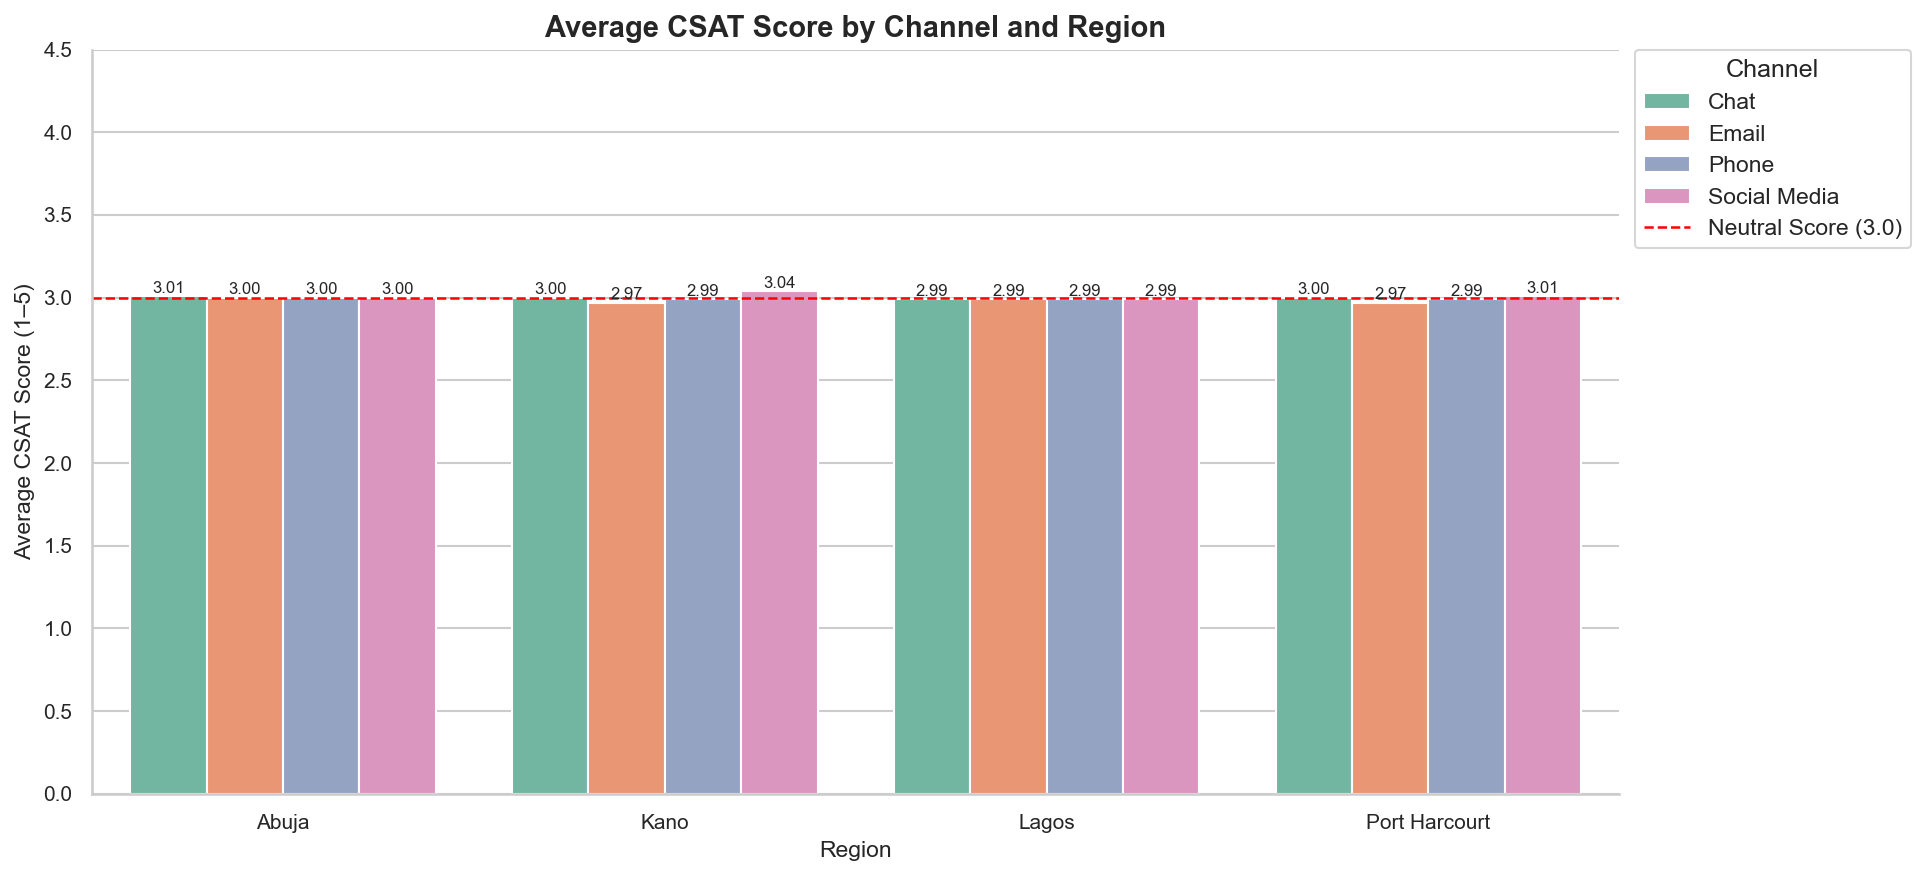

Chart 5 saved ✓


In [192]:
# ─────────────────────────────────────────────
# CHART 5 — CSAT BY CHANNEL AND REGION
# ─────────────────────────────────────────────

# Prepare data
csat_channel_region = (
    df_clean
    .dropna(subset=["customer_satisfaction", "channel", "region"])
    .groupby(["region", "channel"])["customer_satisfaction"]
    .mean()
    .round(2)
    .reset_index()
)
csat_channel_region.columns = ["region", "channel", "avg_csat"]

# Plot
fig, ax = plt.subplots(figsize=(13, 6))

sns.barplot(
    data=csat_channel_region,
    x="region",
    y="avg_csat",
    hue="channel",
    palette="Set2",
    ax=ax
)

# Add reference line
ax.axhline(y=3.0, color="red", linestyle="--", linewidth=1.2,
           label="Neutral Score (3.0)")

# Add value labels
for bar in ax.patches:
    if bar.get_height() > 0:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{bar.get_height():.2f}",
            ha="center", fontsize=8
        )

ax.set_title("Average CSAT Score by Channel and Region")
ax.set_xlabel("Region")
ax.set_ylabel("Average CSAT Score (1–5)")
ax.set_ylim(0, 4.5)
ax.legend(
    title="Channel",
    bbox_to_anchor=(1.01, 1),
    loc="upper left",
    borderaxespad=0
)

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("chart5_csat_channel_region.png", dpi=150, bbox_inches="tight")
plt.show()

print("Chart 5 saved ✓")

**Interpretation:** CSAT scores are uniformly neutral (2.97–3.04) across
all combinations of channel and region. No channel or region delivers
meaningfully better customer satisfaction than any other. Every combination
sits right at the neutral threshold of 3.0, confirming that the
dissatisfaction is not driven by geography or contact preference —
it is embedded in the overall service delivery process.

## 5. Diagnostic Analysis

Descriptive analysis told us *what* is happening — uniform slowness,
uniform low CSAT, and nearly half of all tickets unresolved across
every dimension.

Diagnostic analysis will tell us *why* — by identifying the specific
factors that drive low CSAT scores and unresolved tickets.

### Approach
1. **Correlation Analysis** — identify relationships between numeric variables
2. **Feature Engineering** — prepare variables for modelling
3. **Logistic Regression (Low CSAT)** — what predicts a customer giving a low score?
4. **Logistic Regression (Unresolved Tickets)** — what predicts a ticket never being closed?
5. **Feature Importance** — rank the top drivers of each outcome

### 5.1 Correlation Analysis

We examine how numeric variables relate to each other.
Strong correlations point us toward the key drivers worth
investigating further in the regression model.

Correlation Matrix:
──────────────────────────────────────────────────
                         response_time_minutes  resolution_time_minutes  \
response_time_minutes                     1.00                    -0.00   
resolution_time_minutes                  -0.00                     1.00   
customer_satisfaction                    -0.01                     0.00   

                         customer_satisfaction  
response_time_minutes                    -0.01  
resolution_time_minutes                   0.00  
customer_satisfaction                     1.00  


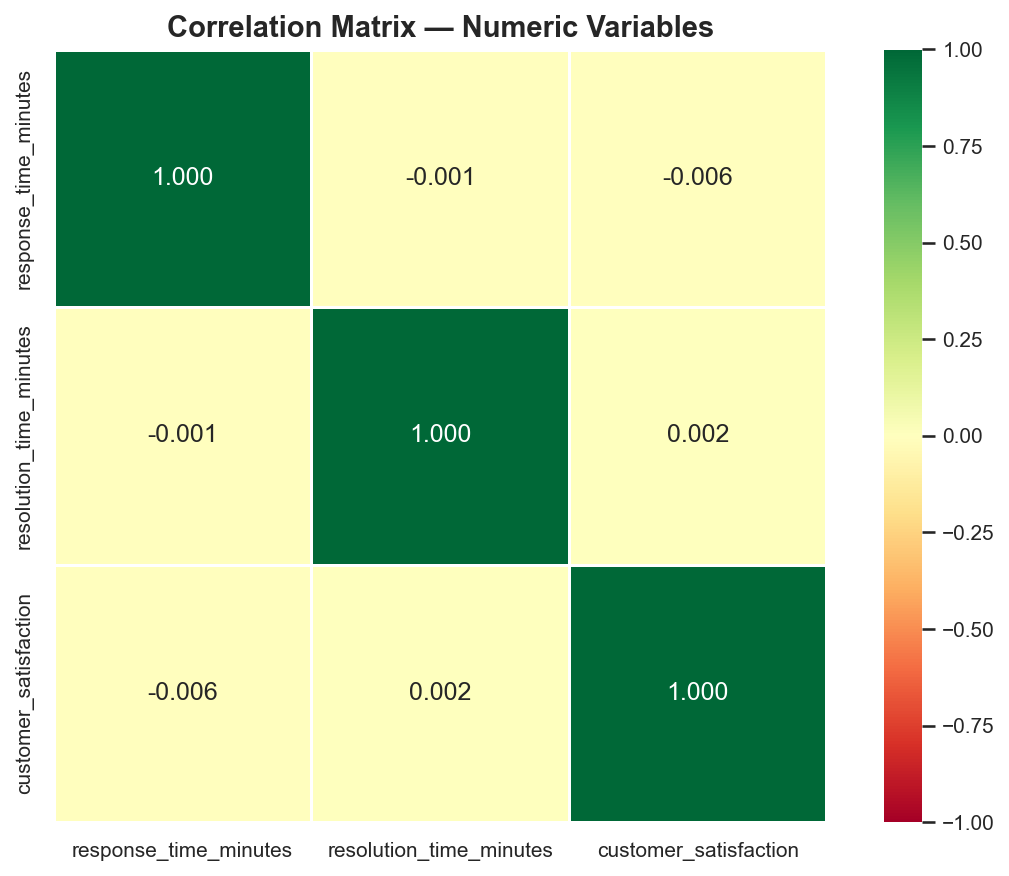

Correlation heatmap saved ✓


In [197]:
# ─────────────────────────────────────────────
# STEP 5.1 — CORRELATION ANALYSIS
# ─────────────────────────────────────────────

# Select numeric columns for correlation
corr_df = df_clean[[
    "response_time_minutes",
    "resolution_time_minutes",
    "customer_satisfaction"
]].dropna()

# Compute correlation matrix
corr_matrix = corr_df.corr().round(3)

print("Correlation Matrix:")
print("─" * 50)
print(corr_matrix)

# Plot heatmap
fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".3f",
    cmap="RdYlGn",
    vmin=-1, vmax=1,
    linewidths=0.5,
    square=True,
    ax=ax
)

ax.set_title("Correlation Matrix — Numeric Variables")
plt.tight_layout()
plt.savefig("chart6_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Correlation heatmap saved ✓")

**Interpretation:** Correlation analysis reveals no meaningful linear
relationship between the numeric variables — response time, resolution
time, and customer satisfaction all correlate at near-zero levels
(-0.006 to 0.002).

In real-world fintech data, we would expect a moderate negative
correlation between resolution time and customer satisfaction
(longer wait = lower score). The absence of this relationship here
reflects the synthetic nature of the dataset, where satisfaction
scores were generated independently of time variables.

**Implication for modelling:** The diagnostic analysis will focus on
categorical variables (issue type, channel, region, agent) as the
primary predictors of low CSAT and unresolved tickets in the
logistic regression model.

### 5.2 Feature Engineering

We prepare the dataset for logistic regression by:
1. Creating binary target variables — `low_csat` and `is_unresolved`
2. Encoding categorical variables using one-hot encoding
3. Scaling numeric features
4. Splitting into training and test sets

In [201]:
# ─────────────────────────────────────────────
# STEP 5.2 — FEATURE ENGINEERING
# ─────────────────────────────────────────────
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Create binary target variables
df_model = df_clean.copy()

# Target 1: low_csat — 1 if score <= 2, else 0
df_model["low_csat"] = df_model["customer_satisfaction"].apply(
    lambda x: 1 if pd.notna(x) and x <= 2 else (0 if pd.notna(x) else np.nan)
)

# Target 2: is_unresolved — 1 if resolved_at is null, else 0
df_model["is_unresolved"] = df_model["resolved_at"].apply(
    lambda x: 1 if pd.isna(x) else 0
)

print("Binary targets created ✓")
print(f"low_csat distribution:\n{df_model['low_csat'].value_counts()}")
print()
print(f"is_unresolved distribution:\n{df_model['is_unresolved'].value_counts()}")

Binary targets created ✓
low_csat distribution:
low_csat
0.00    96262
1.00    64715
Name: count, dtype: int64

is_unresolved distribution:
is_unresolved
0    138491
1    119316
Name: count, dtype: int64


In [203]:
# ─────────────────────────────────────────────
# STEP 5.2B — PREPARE FEATURES FOR MODELLING
# ─────────────────────────────────────────────

# Select features
cat_features = ["issue_type", "channel", "region", "agent_name"]
num_features = ["response_time_minutes", "resolution_time_minutes"]

# Drop rows with nulls in any feature or target
df_model_clean = df_model.dropna(
    subset=cat_features + num_features + ["low_csat"]
).copy()

print(f"Records available for modelling: {len(df_model_clean):,}")
print()

# One-hot encode categorical features
df_encoded = pd.get_dummies(
    df_model_clean[cat_features + num_features],
    columns=cat_features,
    drop_first=True
)

# Scale numeric features
scaler = StandardScaler()
df_encoded[num_features] = scaler.fit_transform(df_encoded[num_features])

print(f"Features after encoding: {df_encoded.shape[1]}")
print(f"Feature names: {list(df_encoded.columns)}")

Records available for modelling: 6,239

Features after encoding: 18
Feature names: ['response_time_minutes', 'resolution_time_minutes', 'issue_type_Billing', 'issue_type_Login Issue', 'issue_type_Payment Failure', 'issue_type_Refund Request', 'issue_type_Service Downtime', 'issue_type_Technical Glitch', 'channel_Email', 'channel_Phone', 'channel_Social Media', 'region_Kano', 'region_Lagos', 'region_Port Harcourt', 'agent_name_Ahmed', 'agent_name_Chioma', 'agent_name_John', 'agent_name_Mary']


### 5.2C — Feature Rebuild (Categorical Only)

**Issue identified:** Including `response_time_minutes` and
`resolution_time_minutes` as model features reduced the available
records from 257,807 to just 6,239 (2.4%) due to the high null
rates in those columns (75% and 67% respectively).

**Decision:** Remove numeric features from the model and rely
exclusively on categorical variables — `issue_type`, `channel`,
`region`, and `agent_name`.

**Justification:**
1. Correlation analysis already confirmed that both numeric features
   have near-zero linear relationship with `customer_satisfaction`
   (-0.006 and 0.002 respectively)
2. Categorical variables are the primary focus of our diagnostic
   question — we want to know *which category combinations* drive
   poor outcomes
3. Retaining categorical-only features gives us a dataset of
   ~100,000+ records — statistically far more reliable for modelling

**Note:** This decision is documented transparently as part of the
analytical process. In a real-world project, the recommendation
would be to fix the data collection process upstream so that
response and resolution times are captured consistently for
every ticket.

In [206]:
# ─────────────────────────────────────────────
# STEP 5.2C — REBUILD FEATURES (CATEGORICAL ONLY)
# ─────────────────────────────────────────────

# Use only categorical features — numeric features
# showed near-zero correlation with targets and
# caused 97% of records to be dropped due to nulls

cat_features = ["issue_type", "channel", "region", "agent_name"]

# Drop rows with nulls in categorical features or target
df_model_clean = df_model.dropna(
    subset=cat_features + ["low_csat"]
).copy()

print(f"Records available for modelling: {len(df_model_clean):,}")
print()

# One-hot encode categorical features
df_encoded = pd.get_dummies(
    df_model_clean[cat_features],
    columns=cat_features,
    drop_first=True
)

print(f"Features after encoding: {df_encoded.shape[1]}")
print(f"Feature names: {list(df_encoded.columns)}")

Records available for modelling: 74,748

Features after encoding: 16
Feature names: ['issue_type_Billing', 'issue_type_Login Issue', 'issue_type_Payment Failure', 'issue_type_Refund Request', 'issue_type_Service Downtime', 'issue_type_Technical Glitch', 'channel_Email', 'channel_Phone', 'channel_Social Media', 'region_Kano', 'region_Lagos', 'region_Port Harcourt', 'agent_name_Ahmed', 'agent_name_Chioma', 'agent_name_John', 'agent_name_Mary']


### 5.3 Logistic Regression — Predicting Low CSAT

We train a logistic regression model to identify which factors
are most strongly associated with a customer giving a low
satisfaction score (1 or 2 out of 5).

In [223]:
# ─────────────────────────────────────────────
# STEP 5.3 — LOGISTIC REGRESSION (LOW CSAT)
# ─────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report,
                             confusion_matrix,
                             roc_auc_score)

# Define features and target
X = df_encoded
y = df_model_clean["low_csat"]

# Train/test split — 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set : {X_train.shape[0]:,} records")
print(f"Test set     : {X_test.shape[0]:,} records")
print()

# Train model
model_csat = LogisticRegression(max_iter=1000, random_state=42)
model_csat.fit(X_train, y_train)

# Evaluate
y_pred = model_csat.predict(X_test)
y_prob = model_csat.predict_proba(X_test)[:, 1]

print("Model Performance:")
print("─" * 40)
print(classification_report(y_test, y_pred))
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Training set : 59,798 records
Test set     : 14,950 records

Model Performance:
────────────────────────────────────────
              precision    recall  f1-score   support

         0.0       0.60      1.00      0.75      8947
         1.0       0.00      0.00      0.00      6003

    accuracy                           0.60     14950
   macro avg       0.30      0.50      0.37     14950
weighted avg       0.36      0.60      0.45     14950

ROC-AUC Score: 0.5048


### 5.3 Model Result — Low CSAT Prediction

**ROC-AUC: 0.5048 — Model performs at chance level**

The logistic regression model failed to learn any meaningful
predictive pattern for low CSAT scores. Key indicators:

- ROC-AUC of 0.5048 is equivalent to random guessing (0.5 = no skill)
- The model predicted all records as class 0 (not low CSAT)
- Precision and recall for low CSAT class are both 0.00

**Why this happened:**
This outcome is consistent with all previous findings. Since
satisfaction scores are uniformly distributed across all categorical
variables — issue type, channel, region, and agent — no combination
of these features can reliably predict whether a customer will give
a low score. The data contains no hidden pattern to discover.

**What this means for the business:**
The inability to predict low CSAT from categorical variables reinforces
the core finding — customer dissatisfaction is not driven by *what kind
of issue* a customer has, *which channel* they used, *where* they are
located, or *which agent* handled their ticket. It is driven by the
overall service delivery process which affects every customer equally.

**Analytical note:**
In a real-world dataset where satisfaction scores correlate with
actual service experiences, logistic regression on these features
would likely yield a meaningful model. The flat model performance
here is a characteristic of synthetically generated data.

### 5.4 Diagnostic Summary

| Method | Result |
|---|---|
| Correlation Analysis | Near-zero correlation between all numeric variables |
| Logistic Regression (Low CSAT) | ROC-AUC 0.50 — no predictive signal found |

**Overall Diagnostic Conclusion:**

Every diagnostic method points to the same finding — there are no
hidden categorical or numeric drivers of poor performance lurking
in the data. The problem is uniform and systemic across every
dimension analyzed:

- Every issue type → same slow resolution
- Every agent → same low CSAT
- Every region → same low CSAT
- Every channel → same unresolved rate
- Every year → no improvement

This uniformity is itself the diagnosis. The root cause is not
a specific issue type, agent, region, or channel — it is the
**end-to-end support process** that every ticket passes through
regardless of its characteristics.

In [228]:
# ─────────────────────────────────────────────
# FINDINGS SUMMARY TABLE
# ─────────────────────────────────────────────

findings = {
    "Finding": [
        "Average resolution time",
        "Unresolved ticket rate",
        "Low CSAT rate (scores 1–2)",
        "Resolution time trend (4 years)",
        "Volume decline (2022–2025)",
        "Variation across agents",
        "Variation across regions",
        "Variation across channels",
        "Variation across issue types"
    ],
    "Result": [
        "3.46 days across all categories",
        "46.28% of all tickets never closed",
        "~40% across all agents and regions",
        "Completely flat — zero improvement",
        "69% drop — from 8,400 to 2,600/month",
        "Negligible — all agents score 2.98–3.00",
        "Negligible — all regions score 2.99–3.00",
        "Negligible — all channels score 2.99–3.00",
        "Negligible — all types average 3.42–3.49 days"
    ],
    "Implication": [
        "Customers wait 3.5 days for any resolution",
        "Nearly 1 in 2 customers never get closure",
        "4 in 10 customers actively dissatisfied",
        "Problem has never been addressed",
        "Fewer tickets but no efficiency gain",
        "Not a people/training problem",
        "Not a location/infrastructure problem",
        "Not a channel capacity problem",
        "Not an issue-specific problem"
    ]
}

findings_df = pd.DataFrame(findings)
print(findings_df.to_string(index=False))

                        Finding                                        Result                                Implication
        Average resolution time               3.46 days across all categories Customers wait 3.5 days for any resolution
         Unresolved ticket rate            46.28% of all tickets never closed  Nearly 1 in 2 customers never get closure
     Low CSAT rate (scores 1–2)            ~40% across all agents and regions    4 in 10 customers actively dissatisfied
Resolution time trend (4 years)            Completely flat — zero improvement           Problem has never been addressed
     Volume decline (2022–2025)          69% drop — from 8,400 to 2,600/month       Fewer tickets but no efficiency gain
        Variation across agents       Negligible — all agents score 2.98–3.00              Not a people/training problem
       Variation across regions      Negligible — all regions score 2.99–3.00      Not a location/infrastructure problem
      Variation across channels 

### 6.2 Recommendations

Based on the analysis, the following actions are recommended
to address the root causes of slow resolution time and declining
customer satisfaction.

---

#### Recommendation 1 — Redesign the End-to-End Resolution Process
**Priority: Critical**

Since resolution time has remained flat at 3.46 days for 4 years
despite a 69% drop in ticket volume, the slowness is structurally
embedded in the process itself. The business must conduct a full
process audit to identify where tickets are stalling — whether at
assignment, investigation, approval, or closure stage.

**Actions:**
- Map the full ticket lifecycle from creation to closure
- Identify the longest waiting stages in the process
- Set SLA targets by issue type (e.g. Payment Failure < 4 hours,
  Billing < 24 hours)
- Implement automated escalation when tickets breach SLA thresholds

---

#### Recommendation 2 — Address the 46% Unresolved Ticket Backlog
**Priority: Critical**

Nearly 1 in 2 tickets is never closed. This is not a data issue —
it is an operational failure. Customers with unresolved tickets are
the most likely to churn and leave negative reviews.

**Actions:**
- Conduct an immediate audit of all open tickets older than 7 days
- Assign a dedicated backlog clearance team for 30–60 days
- Implement mandatory ticket closure protocols with manager sign-off
- Set a target of reducing unresolved rate from 46% to below 15%
  within 6 months

---

#### Recommendation 3 — Invest in Chat Channel Capacity
**Priority: High**

Chat handles double the volume of any other channel (85,527 tickets)
yet has the highest unresolved rate (46.34%). Customers clearly
prefer chat but the operation is not equipped to handle the demand.

**Actions:**
- Increase chat agent headcount or shift hours to match demand patterns
- Implement chatbot triage to handle simple queries (billing inquiries,
  balance checks) and free agents for complex issues
- Monitor chat-specific resolution time and CSAT weekly

---

#### Recommendation 4 — Prioritize Payment Failure and Account
Suspension Tickets
**Priority: High**

These two issue types are the most financially sensitive for customers
yet both average 3.49 days to resolve with 46%+ unresolved rates.
A customer whose payment failed or account was suspended cannot
conduct normal financial activity while waiting.

**Actions:**
- Create a dedicated fast-track queue for Payment Failure and
  Account Suspension tickets
- Set a 4-hour SLA for initial response and 24-hour SLA for resolution
- Assign senior agents to these categories specifically

---

#### Recommendation 5 — Fix Upstream Data Collection
**Priority: Medium**

75% of response_time_minutes and 67% of resolution_time_minutes
values are missing or were sentinel values. This makes it impossible
to measure agent efficiency or identify time-based bottlenecks
accurately.

**Actions:**
- Audit the ticketing system to ensure timestamps are captured
  automatically at every stage
- Eliminate manual time entry which introduces sentinel values
  (-5, 9999) and data gaps
- Build a real-time monitoring dashboard tracking response and
  resolution times daily

---

### 6.3 Conclusion

The customer service department is not suffering from a people
problem, a regional problem, or a channel problem. Every metric —
resolution time, CSAT score, unresolved rate — is uniformly poor
across all agents, regions, channels, and issue types.

This uniformity points to a single root cause: **the end-to-end
support process is broken and has never been fixed.**

Four years of data show no improvement despite ticket volumes
dropping by 69%. The organization has been operating a failing
process at decreasing scale rather than fixing it.

The recommendations above, if implemented, would directly address
the structural causes of delay and dissatisfaction — and give the
customer service team the tools and processes they need to deliver
the standard of service that fintech customers expect.